# Consultas – HBase
Dataset: *eCommerce Purchase History from Electronics Store*

**Nota:** HBase no tiene motor de agregación nativo como MongoDB o los ZSETs de Redis.  
Las consultas de agregación se realizan mediante **scan + procesamiento en Python**.

**Consultas:** categoría más vendida · marca con más ingresos · mes con más ventas (UTC)

In [23]:
import happybase
import pandas as pd
import time
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

conn  = happybase.Connection('localhost', port=9090)
conn.open()
table = conn.table('ecommerce')
print('Conexión a HBase establecida.')

Conexión a HBase establecida.


## Q1 – Categoría más vendida
Scan de la columna `product:cat` y conteo en Python.

Tiempo de respuesta: 25.560s


,category,count
0,nan,612053
1,electronics.smartphone,357581
2,appliances.kitchen.refrigerators,77371
3,16.18,72969
4,electronics.video.tv,71695
5,computers.notebook,71416
6,appliances.environment.vacuum,66438
7,electronics.audio.headphone,66141
8,appliances.kitchen.kettle,62702
9,appliances.kitchen.washer,56236


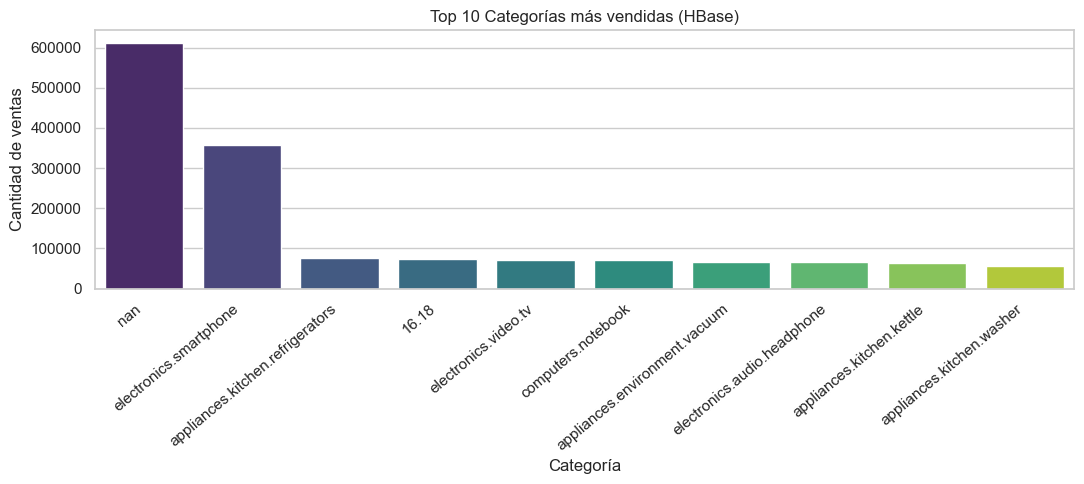

In [18]:
t0      = time.time()
counter = Counter()

for _key, data in table.scan(columns=[b'product:cat']):
    cat = data.get(b'product:cat', b'unknown').decode(errors='replace')
    counter[cat] += 1

elapsed_q1 = time.time() - t0

df_q1 = pd.DataFrame(counter.most_common(10), columns=['category', 'count'])
print(f'Tiempo de respuesta: {elapsed_q1:.3f}s')
display(df_q1)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=df_q1, x='category', y='count', hue='category', palette='viridis', legend=False, ax=ax)
ax.set_title('Top 10 Categorías más vendidas (HBase)')
ax.set_xlabel('Categoría')
ax.set_ylabel('Cantidad de ventas')
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()


## Q2 – Marca con más ingresos brutos
Scan de columnas `product:brand` y `product:price`, acumulación en Python.

Tiempo de respuesta: 32.558s


,brand,revenue_usd
0,samsung,90024615.05
1,apple,47893470.39
2,lg,26148633.49
3,bosch,11075932.70
4,huawei,10772736.47
5,asus,10634387.10
6,karcher,256217.44
7,nan,NaN
8,lenovo,10525822.64
9,ava,8540869.03


C:\Users\cordo\AppData\Local\Temp\ipykernel_13684\1878514024.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_q2, x='brand', y='revenue_usd', palette='magma', ax=ax)
C:\Users\cordo\AppData\Local\Temp\ipykernel_13684\1878514024.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')


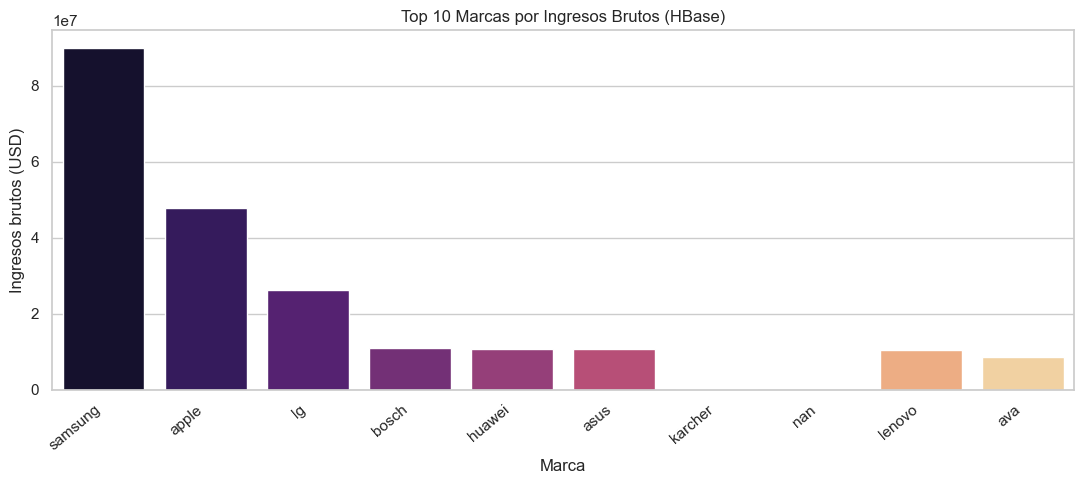

In [19]:
t0      = time.time()
revenue = defaultdict(float)

for _key, data in table.scan(columns=[b'product:brand', b'product:price']):
    brand = data.get(b'product:brand', b'unknown').decode(errors='replace') or 'unknown'
    try:
        price = float(data.get(b'product:price', b'0').decode())
    except ValueError:
        price = 0.0
    revenue[brand] += price

elapsed_q2 = time.time() - t0

df_q2 = pd.DataFrame(sorted(revenue.items(), key=lambda x: x[1], reverse=True)[:10],
                     columns=['brand', 'revenue_usd'])
df_q2['revenue_usd'] = df_q2['revenue_usd'].round(2)
print(f'Tiempo de respuesta: {elapsed_q2:.3f}s')
display(df_q2)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=df_q2, x='brand', y='revenue_usd', palette='magma', ax=ax)
ax.set_title('Top 10 Marcas por Ingresos Brutos (HBase)')
ax.set_xlabel('Marca')
ax.set_ylabel('Ingresos brutos (USD)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()

## Q3 – Mes con más ventas (UTC)
Scan de `event:time`, parse de fecha y agrupación por mes.

In [ ]:
t0           = time.time()
month_counts = Counter()

for _key, data in table.scan(columns=[b'event:time']):
    raw = data.get(b'event:time', b'').decode(errors='replace')
    try:
        month = pd.to_datetime(raw, utc=True).strftime('%Y-%m')
    except Exception:
        month = 'unknown'
    month_counts[month] += 1

elapsed_q3 = time.time() - t0

df_q3 = pd.DataFrame(month_counts.items(), columns=['month', 'count'])
df_q3 = df_q3[df_q3['month'] != 'unknown'].sort_values('month')
print(f'Tiempo de respuesta: {elapsed_q3:.3f}s')
display(df_q3)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=df_q3, x='month', y='count', marker='o', color='darkorange', ax=ax)
ax.fill_between(df_q3['month'], df_q3['count'], alpha=0.15, color='darkorange')
ax.set_title('Ventas por Mes (HBase – UTC)')
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad de ventas')
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()


## Resumen de tiempos de respuesta

In [21]:
tiempos = pd.DataFrame({
    'consulta': ['Q1 – Categoría más vendida', 'Q2 – Marca con más ingresos', 'Q3 – Mes con más ventas'],
    'tiempo_s': [elapsed_q1, elapsed_q2, elapsed_q3]
})
display(tiempos)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=tiempos, x='consulta', y='tiempo_s', palette='coolwarm', ax=ax)
ax.set_title('Tiempos de respuesta (HBase)')
ax.set_ylabel('Segundos')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()

conn.close()

NameError: name 'elapsed_q3' is not defined